# Legal Clause Classification Training Notebook

This notebook serves as the main training file for a legal clause classification model. It demonstrates the full pipeline from data loading and preprocessing to model training, evaluation, and comparative experimentation. We will be using a Legal-BERT-based classifier to identify specific legal clauses within contracts.

The notebook is structured into logical sections to facilitate understanding and reproducibility:

1.  **Initial Setup**: Environment configuration and file preparation.
2.  **Dataset Loading**: Loading preprocessed contractual data splits.
3.  **Tokenizer (Legal-BERT)**: Initializing the appropriate tokenizer for our model.
4.  **Dataset + DataLoader**: Preparing data for batch processing during training.
5.  **Model**: Defining the Legal-BERT-based classification model.
6.  **Weighted Loss**: Implementing a custom loss function to handle class imbalance.
7.  **Optimizer**: Setting up the optimization algorithm.
8.  **Training Loop**: The core training process for the model.
9.  **Evaluation**: Assessing model performance with key metrics.
10. **Experiment 2**: A comparative experiment to analyze the impact of the `use_length_feature` parameter.

## 0. Initial Setup

Before we begin with the model training, we need to set up our environment by unzipping the necessary source files and data, configuring the Python path, and verifying our hardware setup.

In [8]:
!unzip phase2_colab.zip

Archive:  phase2_colab.zip
   creating: src/phase2/
   creating: src/phase2/segmentation/
  inflating: src/phase2/segmentation/clause_splitter.py  
  inflating: src/phase2/segmentation/sequence_labeling.py  
   creating: src/phase2/training/
  inflating: src/phase2/training/metrics.py  
  inflating: src/phase2/training/loss.py  
  inflating: src/phase2/training/trainer.py  
   creating: src/phase2/ocr/
  inflating: src/phase2/ocr/ocr_engine.py  
  inflating: src/phase2/ocr/preprocessing.py  
  inflating: src/phase2/__init__.py  
   creating: src/phase2/utils/
  inflating: src/phase2/utils/config.py  
  inflating: src/phase2/utils/logger.py  
  inflating: src/phase2/utils/seed.py  
   creating: src/phase2/models/
  inflating: src/phase2/models/bert_classifier.py  
  inflating: src/phase2/models/multitask_model.py  
   creating: src/phase2/evaluation/
  inflating: src/phase2/evaluation/confusion_matrix.py  
  inflating: src/phase2/evaluation/evaluator.py  
   creating: src/phase2/data/
 


### Unzipping Project Files

This command extracts the contents of `phase2_colab.zip`, which contains our project's source code (`src/`) and preprocessed data (`data/processed/`). This is crucial for accessing custom modules and datasets.

In [9]:
import sys
sys.path.append("/content")

### Configure Python Path

We add `/content` to the Python system path. This allows us to import modules directly from the unzipped `src` directory without needing to specify the full path, simplifying our code.

In [10]:
!ls data/processed

dataset_manifest.json  label2id.json  test.csv	train.csv  val.csv


### Verify Processed Data

This command lists the files within the `data/processed` directory. These files include the training, validation, and test datasets (`train.csv`, `val.csv`, `test.csv`), as well as metadata like `label2id.json` (mapping labels to numerical IDs) and `dataset_manifest.json` (dataset statistics).

In [11]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


### Check for GPU Availability

It's important to verify if a CUDA-enabled GPU is available, as training deep learning models like Legal-BERT is significantly faster on GPUs. We also print the name of the GPU being used.

### 1. Load Dataset

In [12]:
from src.phase2.data.dataset_loader import load_processed_splits

train_df, val_df, test_df, label2id = load_processed_splits(
    "data/processed/train.csv",
    "data/processed/val.csv",
    "data/processed/test.csv",
    label2id_path="data/processed/label2id.json"
)

num_classes = len(label2id)
print("Classes:", num_classes)

Classes: 41


### 2. Tokenizer (Legal-BERT)

In [13]:
from transformers import AutoTokenizer

MODEL_NAME = "nlpaueb/legal-bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

### 3. Dataset + DataLoader

In [14]:
from torch.utils.data import DataLoader
from src.phase2.data.dataset import ContractDataset

MAX_LENGTH = 384   # important for speed
BATCH_SIZE = 32

train_dataset = ContractDataset(train_df, tokenizer, max_length=MAX_LENGTH)
val_dataset = ContractDataset(val_df, tokenizer, max_length=MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

### 4. Model

In [15]:
import torch
from src.phase2.models.bert_classifier import BertWithLengthClassifier

device = torch.device("cuda")

model = BertWithLengthClassifier(
    MODEL_NAME,
    num_classes=num_classes,
    dropout=0.1,
    use_length_feature=True,
).to(device)

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 5. Weighted Loss (IMPORTANT 🔥)

In [16]:
import json
import torch.nn as nn

with open("data/processed/dataset_manifest.json") as f:
    manifest = json.load(f)

label_counts_by_name = manifest["label_counts_train"]

# Create a list to store weights, indexed by class ID
weights_list = [0.0] * num_classes

# Populate weights_list using label2id to map IDs to names
for label_name, label_id in label2id.items():
    weights_list[label_id] = 1.0 / label_counts_by_name[label_name]

# Convert to tensor weights
weights = torch.tensor(
    weights_list,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

### 6. Optimizer

In [17]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=1.5e-5)

### 7. TRAINING LOOP (FINAL)

In [18]:
from tqdm import tqdm

EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        length_feat = batch["length_feat"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            length_feat=length_feat
        )

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

Epoch 1: 100%|██████████| 169/169 [05:36<00:00,  1.99s/it]


Epoch 1 Loss: 583.6325


Epoch 2: 100%|██████████| 169/169 [05:51<00:00,  2.08s/it]


Epoch 2 Loss: 402.5472


Epoch 3: 100%|██████████| 169/169 [05:53<00:00,  2.09s/it]


Epoch 3 Loss: 272.7730


Epoch 4: 100%|██████████| 169/169 [05:52<00:00,  2.09s/it]


Epoch 4 Loss: 187.4027


Epoch 5: 100%|██████████| 169/169 [05:53<00:00,  2.09s/it]

Epoch 5 Loss: 134.5713


In [19]:
!pip install scikit-learn

In [20]:
from sklearn.metrics import f1_score, accuracy_score
import torch

model.eval()

all_preds = []
all_labels = []

val_loss = 0

with torch.no_grad():
    for batch in val_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        length_feat = batch["length_feat"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            length_feat=length_feat
        )

        loss = criterion(outputs, labels)
        val_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [21]:
macro_f1 = f1_score(all_labels, all_preds, average="macro")
accuracy = accuracy_score(all_labels, all_preds)

print("Validation Loss:", val_loss)
print("Macro F1:", macro_f1)
print("Accuracy:", accuracy)

Validation Loss: 17.832698583602905
Macro F1: 0.7506149487469685
Accuracy: 0.820627802690583


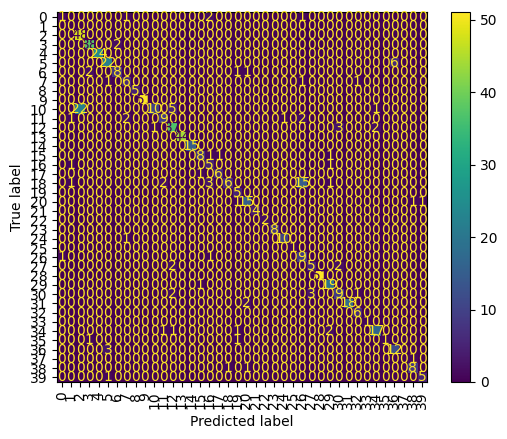

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=90)
plt.show()

### Experiment 2: `use_length_feature=False`

In [23]:
import torch
from src.phase2.models.bert_classifier import BertWithLengthClassifier

# Re-initialize the model for Experiment 2 with use_length_feature=False
model_exp2 = BertWithLengthClassifier(
    MODEL_NAME,
    num_classes=num_classes,
    dropout=0.1,
    use_length_feature=False, # Changed to False for Experiment 2
).to(device)
print("Model for Experiment 2 initialized with use_length_feature=False.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model for Experiment 2 initialized with use_length_feature=False.


#### Optimizer for Experiment 2

In [24]:
from torch.optim import AdamW

optimizer_exp2 = AdamW(model_exp2.parameters(), lr=1.5e-5)
print("Optimizer for Experiment 2 initialized.")

Optimizer for Experiment 2 initialized.


#### Training Loop for Experiment 2

In [25]:
from tqdm import tqdm

EPOCHS = 5

for epoch in range(EPOCHS):
    model_exp2.train()
    total_loss_exp2 = 0

    for batch in tqdm(train_loader, desc=f"Experiment 2 Epoch {epoch+1}"):

        optimizer_exp2.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        length_feat = batch["length_feat"].to(device)

        outputs = model_exp2(
            input_ids=input_ids,
            attention_mask=attention_mask,
            length_feat=length_feat if model_exp2.use_length_feature else None # Conditionally pass length_feat
        )

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_exp2.step()

        total_loss_exp2 += loss.item()

    print(f"Experiment 2 Epoch {epoch+1} Loss: {total_loss_exp2:.4f}")

Experiment 2 Epoch 1: 100%|██████████| 169/169 [05:55<00:00,  2.10s/it]


Experiment 2 Epoch 1 Loss: 570.3515


Experiment 2 Epoch 2: 100%|██████████| 169/169 [05:52<00:00,  2.09s/it]


Experiment 2 Epoch 2 Loss: 384.4533


Experiment 2 Epoch 3: 100%|██████████| 169/169 [05:52<00:00,  2.08s/it]


Experiment 2 Epoch 3 Loss: 257.3223


Experiment 2 Epoch 4: 100%|██████████| 169/169 [05:52<00:00,  2.08s/it]


Experiment 2 Epoch 4 Loss: 178.1630


Experiment 2 Epoch 5: 100%|██████████| 169/169 [05:52<00:00,  2.08s/it]

Experiment 2 Epoch 5 Loss: 129.0100


#### Evaluation for Experiment 2

In [26]:
from sklearn.metrics import f1_score, accuracy_score
import torch

model_exp2.eval()

all_preds_exp2 = []
all_labels_exp2 = []

val_loss_exp2 = 0

with torch.no_grad():
    for batch in val_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        length_feat = batch["length_feat"].to(device)

        outputs = model_exp2(
            input_ids=input_ids,
            attention_mask=attention_mask,
            length_feat=length_feat if model_exp2.use_length_feature else None
        )

        loss = criterion(outputs, labels)
        val_loss_exp2 += loss.item()

        preds = torch.argmax(outputs, dim=1)

        all_preds_exp2.extend(preds.cpu().numpy())
        all_labels_exp2.extend(labels.cpu().numpy())

In [27]:
macro_f1_exp2 = f1_score(all_labels_exp2, all_preds_exp2, average="macro")
accuracy_exp2 = accuracy_score(all_labels_exp2, all_preds_exp2)

print("Experiment 2 Validation Loss:", val_loss_exp2)
print("Experiment 2 Macro F1:", macro_f1_exp2)
print("Experiment 2 Accuracy:", accuracy_exp2)

Experiment 2 Validation Loss: 17.60215762257576
Experiment 2 Macro F1: 0.7362029488979493
Experiment 2 Accuracy: 0.8056801195814649


#### Confusion Matrix for Experiment 2

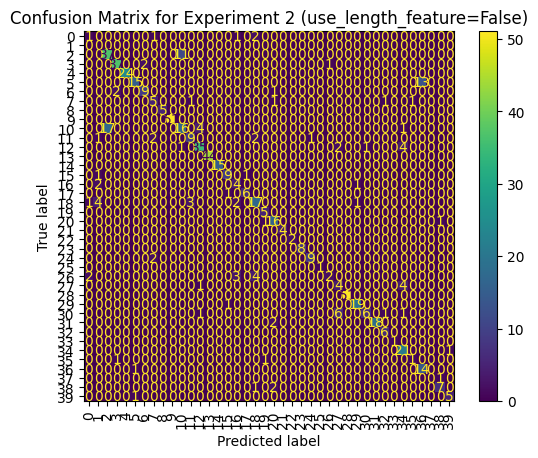

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_exp2 = confusion_matrix(all_labels_exp2, all_preds_exp2)

disp_exp2 = ConfusionMatrixDisplay(confusion_matrix=cm_exp2)
disp_exp2.plot(xticks_rotation=90)
plt.title("Confusion Matrix for Experiment 2 (use_length_feature=False)")
plt.show()